# 1. 读取参考方案

这一步比较供者均衡和上皮拆分。原参考为CID4471、CID4535，开发测试继续使用CID4067的488个模拟spot。

供者均衡在每个原类型内抽取相同数量的两位供者细胞，Cycling T保留原27个。上皮拆分沿用作者的LumA、LumB标签，其余癌上皮归为Cancer Other。两项调整组成三套新参考，与上一轮原参考比较。

生成输入运行`build_reference_comparison.py`，RCTD拟合运行`Rscript src/sc_sncell_github/run_reference_comparison.R`。下面读取保存的RCTD预测并计算NNLS。


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
import runpy
root = Path("/Users/georicl/Documents/sc_sncell_github")
result_dir = root / "results/Wu2021_reference_comparison_v1"
protocol = json.loads((result_dir / "protocol.json").read_text())
display(pd.read_csv(result_dir / "reference_inventory.csv"))


,donor_id,parent_label,reference_label,n_cells,variant
0,CID4471,B-cells,B-cells,56,donor_balanced
1,CID4471,CAFs,CAFs,102,donor_balanced
2,CID4471,Cancer Epithelial,Cancer Epithelial,212,donor_balanced
3,CID4471,Cycling T-cells,Cycling T-cells,8,donor_balanced
4,CID4471,Endothelial,Endothelial,219,donor_balanced
...,...,...,...,...,...
77,CID4535,Normal Epithelial,Normal Epithelial,22,balanced_split
78,CID4535,PVL,PVL,592,balanced_split
79,CID4535,Plasmablasts,Plasmablasts,51,balanced_split
80,CID4535,T cells CD4+,T cells CD4+,239,balanced_split


# 2. 对齐原13类并比较误差

上皮拆分后的三个癌上皮权重相加，得到原标签Cancer Epithelial。主要指标仍为RNA份额MAE，另存细胞份额误差、纯群识别及目标类型缺失时的预测。

NNLS按每套参考重新计算类型特征并选择2000个基因。RCTD保留同样的参数设置，按对应参考重新预处理。


In [2]:
evaluation = runpy.run_path(str(root / "src/sc_sncell_github/evaluate_reference_comparison.py"))
evaluation["main"]()


         variant method  depth_fraction         cell_type    mae_pp
        baseline   RCTD            0.25              CAFs  3.469285
        baseline   RCTD            0.25 Cancer Epithelial 32.465301
        baseline   RCTD            0.25 Normal Epithelial 36.757269
        baseline   RCTD            0.25      T cells CD8+  1.961611
        baseline   RCTD            0.25  Epithelial total  5.228469
        baseline   RCTD            1.00              CAFs  3.600567
        baseline   RCTD            1.00 Cancer Epithelial 31.393695
        baseline   RCTD            1.00 Normal Epithelial 36.323792
        baseline   RCTD            1.00      T cells CD8+  1.730899
        baseline   RCTD            1.00  Epithelial total  5.556159
        baseline   NNLS            0.25              CAFs  4.320725
        baseline   NNLS            0.25 Cancer Epithelial 42.774017
        baseline   NNLS            0.25 Normal Epithelial 42.340582
        baseline   NNLS            0.25      T c

# 3. 查看CAF、CD8和癌上皮

按方法、类型和深度作图。所有柱形从零开始，误差单位为百分点。两个深度版本共享来源细胞，同一测试供者也会在不同配方中复用细胞。


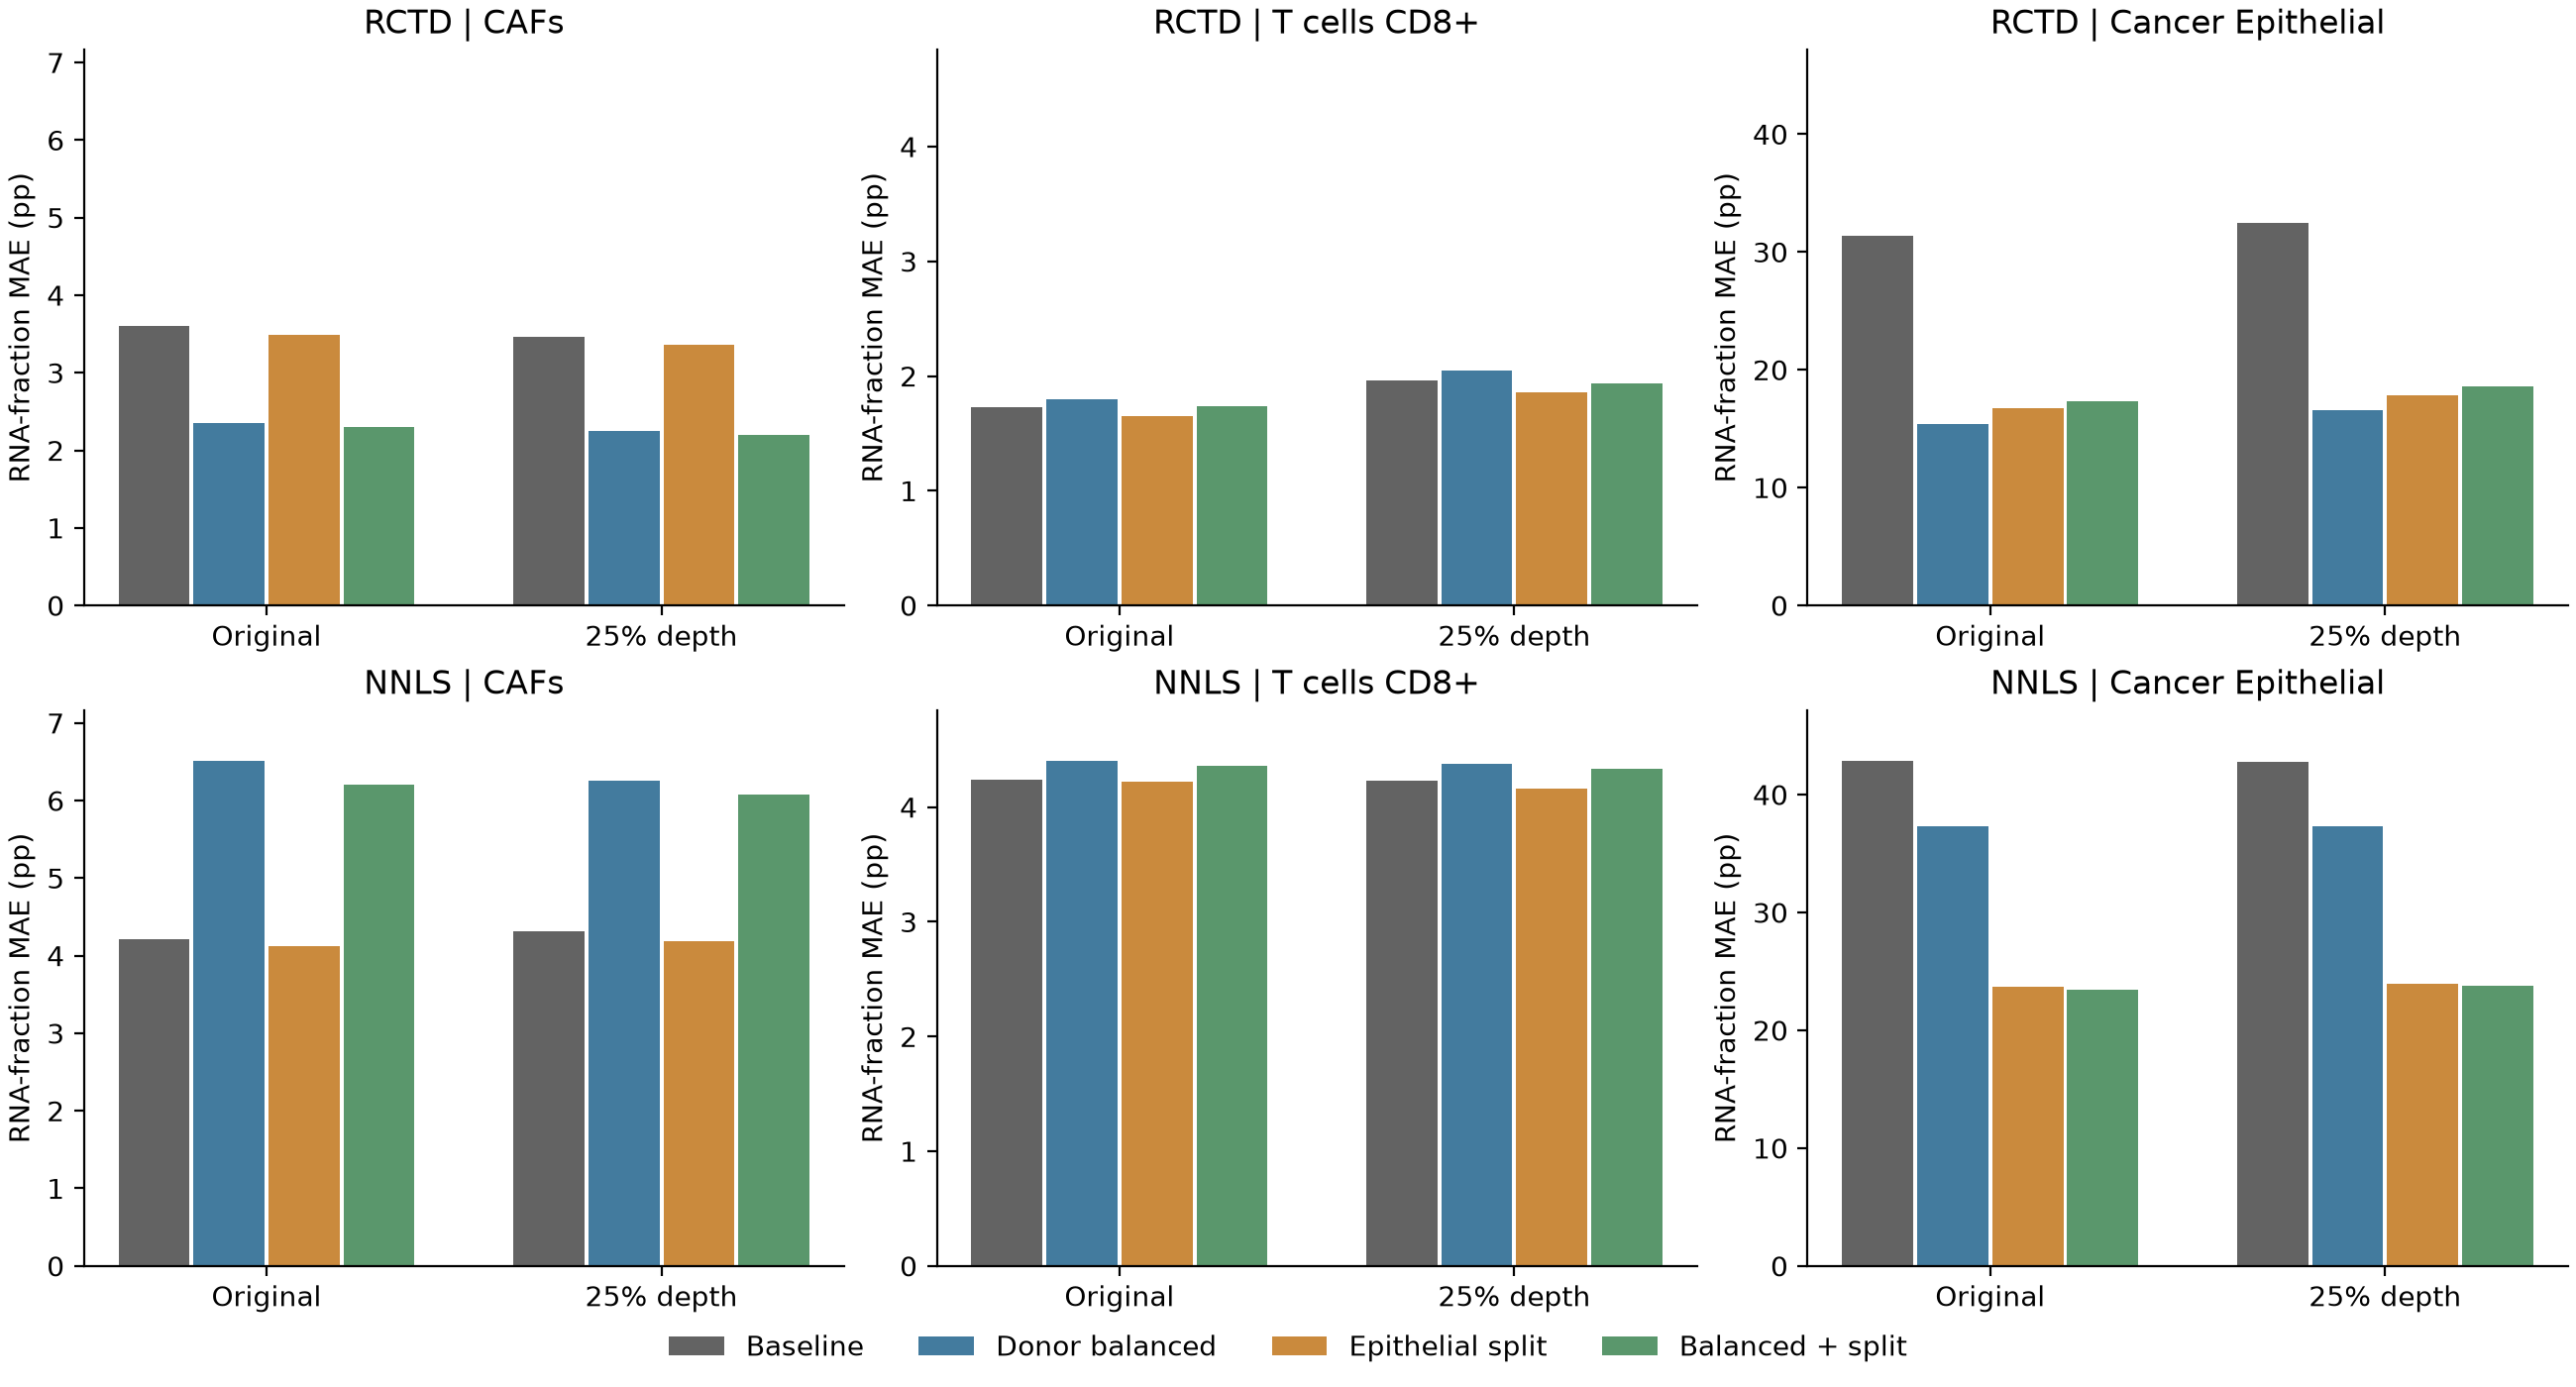

,variant,method,depth_fraction,cell_type,n_spots,dominant_matches,mean_weight_on_true_type,mean_normal_epithelial_weight
1,baseline,RCTD,1.00,CAFs,5,5,0.972873,0.000027
2,baseline,RCTD,1.00,Cancer Epithelial,5,5,0.566753,0.404538
3,baseline,RCTD,1.00,Cycling T-cells,5,0,0.214576,0.000079
10,baseline,RCTD,1.00,T cells CD8+,5,5,0.938160,0.000719
12,baseline,RCTD,0.25,CAFs,5,5,0.955805,0.000022
...,...,...,...,...,...,...,...,...
164,balanced_split,NNLS,1.00,T cells CD8+,5,3,0.466040,0.002567
166,balanced_split,NNLS,0.25,CAFs,5,5,0.973705,0.012277
167,balanced_split,NNLS,0.25,Cancer Epithelial,5,4,0.668400,0.309233
168,balanced_split,NNLS,0.25,Cycling T-cells,5,5,0.868741,0.000000


In [3]:
display(Image(filename=str(result_dir / "reference_comparison.png")))
pure = pd.read_csv(result_dir / "pure_control_summary.csv")
display(pure[pure.cell_type.isin(["CAFs", "T cells CD8+", "Cancer Epithelial", "Cycling T-cells"])])


# 4. 核对来源和评价计算

从原参考计数核对抽样矩阵，检查标签映射和文件哈希，再独立复算MAE、RMSE和平均偏移。原参考指标与上一轮文件对照。


In [4]:
validation = runpy.run_path(str(root / "src/sc_sncell_github/validate_reference_comparison.py"))
checks = json.loads((result_dir / "validation_checks.json").read_text())
print("通过检查：", sum(checks["checks"].values()), "/", len(checks["checks"]))


Checks: 54 passed: 54 max metric difference: 7.105427357601002e-15
通过检查： 54 / 54


# 5. 阅读本轮结果


In [5]:
display(Markdown((result_dir / "interpretation.md").read_text()))


# 参考方案比较

参考为CID4471和CID4535，开发测试使用CID4067的同一批488个模拟spot。原深度和25%深度共享244个基础混合。

## 1. 本轮参考设置

原参考含12570个细胞。供者均衡后保留3799个细胞，每个原类型按较少供者的数量抽样；Cycling T均衡后不足25个，因此保留原27个。抽样使用固定种子20260916。
上皮拆分保留作者LumA和LumB标签，其余癌上皮归为Cancer Other。单独拆分使用全部参考细胞；组合方案使用与供者均衡方案完全相同的细胞。预测后将三类癌上皮相加，按原13类比较。
正常上皮没有删除；它在开发测试中缺失，仍然用于检查误分配。

## 2. RNA份额误差

指标为混合配方MAE，单位为百分点；原深度和25%深度各189个spot。

| 方法 | 参考方案 | 深度 | CAF | CD8 | 癌上皮 | 正常上皮 | 上皮合计 |
|---|---|---|---:|---:|---:|---:|---:|
| RCTD | 原参考 | 1 | 3.60 | 1.73 | 31.39 | 36.32 | 5.56 |
| RCTD | 原参考 | 0.25 | 3.47 | 1.96 | 32.47 | 36.76 | 5.23 |
| RCTD | 供者均衡 | 1 | 2.35 | 1.80 | 15.41 | 18.24 | 3.92 |
| RCTD | 供者均衡 | 0.25 | 2.25 | 2.05 | 16.57 | 18.82 | 3.94 |
| RCTD | 上皮拆分 | 1 | 3.49 | 1.65 | 16.72 | 21.58 | 5.37 |
| RCTD | 上皮拆分 | 0.25 | 3.36 | 1.86 | 17.87 | 22.02 | 5.02 |
| RCTD | 均衡并拆分 | 1 | 2.30 | 1.74 | 17.37 | 19.79 | 3.57 |
| RCTD | 均衡并拆分 | 0.25 | 2.20 | 1.94 | 18.61 | 20.47 | 3.67 |
| NNLS | 原参考 | 1 | 4.21 | 4.24 | 42.86 | 42.57 | 9.26 |
| NNLS | 原参考 | 0.25 | 4.32 | 4.23 | 42.77 | 42.34 | 9.33 |
| NNLS | 供者均衡 | 1 | 6.51 | 4.40 | 37.28 | 31.85 | 11.77 |
| NNLS | 供者均衡 | 0.25 | 6.26 | 4.38 | 37.34 | 31.90 | 11.66 |
| NNLS | 上皮拆分 | 1 | 4.12 | 4.22 | 23.71 | 25.01 | 9.43 |
| NNLS | 上皮拆分 | 0.25 | 4.19 | 4.16 | 23.96 | 25.10 | 9.42 |
| NNLS | 均衡并拆分 | 1 | 6.21 | 4.36 | 23.45 | 25.72 | 11.03 |
| NNLS | 均衡并拆分 | 0.25 | 6.08 | 4.33 | 23.78 | 25.95 | 11.00 |

## 3. 本轮观察

RCTD原深度下，供者均衡将癌上皮MAE从31.39降至15.41个百分点；正常上皮平均错误权重从36.32%降至18.24%。单独上皮拆分的癌上皮MAE为16.72，组合方案为17.37，两项调整没有叠加改善癌上皮识别。
组合方案的CAF MAE为2.30个百分点，原参考为3.60；CD8为1.74，原参考为1.73。单独上皮拆分的CD8 MAE为1.65。25%深度下，各方案的CAF、CD8及癌上皮MAE排序与原深度一致。
供者均衡也使RCTD的PVL MAE从3.49升至3.83，CD4从2.61升至2.86个百分点。没有一套方案在所有类型上都更好。
纯癌上皮对照中，供者均衡后的平均正常上皮权重仍为20.63%，原参考为40.45%。原深度下四套参考的癌上皮主导类型均为5/5匹配，单看主导类型会漏掉这部分误分配。Cycling T仍为0/5匹配。
NNLS的上皮拆分将癌上皮MAE从42.86降至23.71；供者均衡则使CAF MAE从4.21升至6.51。参考调整在两种方法上的影响不同。
当前可以保留供者均衡和上皮拆分作为后续比较方案，优先补充供者与亚型覆盖。正常上皮在本轮开发测试中全部缺失，均衡方案又将其参考从1988个减至44个；下一轮还需要包含正常上皮的独立供者，检查正常上皮识别是否保持。

## 4. 如何阅读这次比较

正常上皮的真值全部为零，所以该列MAE也等于平均错误分配的权重百分比。上皮合计把癌上皮和正常上皮相加，用于查看总量是否接近已知组成。
供者均衡同时减少了参考细胞数量，例如正常上皮从1988个降为44个，CAF从1394个降为204个；结果变化不能全部归因于供者权重。
LumA参考全部来自CID4471，LumB参考全部来自CID4535。亚型与供者相互对应，本轮不能单独分离两者的影响。
本轮复用已经查看过误差的CID4067，只用于比较参考方案；尚未执行新供者的独立检验。

## 5. 参数和文件

RCTD使用full模式、2个核心、种子9，参考UMI最低100，每个模型类型至少25个细胞。NNLS继续按参考侧类型均值选择2000个基因。拆分类别后，各方法会按新的参考重新选择基因。
参数用法核对：[Bioconductor spacexr文档](https://www.bioconductor.org/packages/release/bioc/manuals/spacexr/man/spacexr.pdf)。本机版本及实际参数另存于各方案的sessionInfo和RDS文件。
comparison_metrics.csv包含全部类型、两种真值和两类配方；pure_control_summary.csv保存纯群识别；paired_error_changes.csv保存相对于原参考的逐spot误差变化。
